In [2]:
!pip install pandas pyarrow

Looking in indexes: https://pypi.python.org/simple, https://nexus.domaintools.cloud/repository/pypi-dt-ci/simple, http://pypi.vm.domaintools.net/batch/dev/+simple/


In [3]:
import pandas as pd

file_path = "secop_bienes.parquet"
df = pd.read_parquet(file_path)
df.head()

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,...,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,...,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,...,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...


In [4]:
# DIMENSIONES DEL DATASET (filas, columnas)
df.shape

(196391, 36)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196391 entries, 0 to 196390
Data columns (total 36 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id_contrato                       196391 non-null  object        
 1   nombre_entidad                    196391 non-null  object        
 2   departamento                      196391 non-null  object        
 3   ciudad                            196391 non-null  object        
 4   orden                             196391 non-null  object        
 5   sector                            196391 non-null  object        
 6   rama                              196391 non-null  object        
 7   entidad_centralizada              196391 non-null  object        
 8   tipo_de_contrato                  196391 non-null  object        
 9   modalidad_de_contratacion         196391 non-null  object        
 10  codigo_de_categoria_principal   

In [6]:
# COLUMNAS CON VALORES NULOS
df.isnull().sum()[df.isnull().sum() > 0]

fecha_de_inicio_del_contrato    2440
documento_proveedor                4
dtype: int64

In [7]:
df.nunique()

id_contrato                         196391
nombre_entidad                        3452
departamento                            34
ciudad                                 676
orden                                    4
sector                                  26
rama                                     5
entidad_centralizada                     2
tipo_de_contrato                         2
modalidad_de_contratacion                9
codigo_de_categoria_principal        10931
objeto_del_contrato                 175297
fecha_de_firma                        2437
fecha_de_inicio_del_contrato          2796
fecha_de_fin_del_contrato             3204
duraci_n_del_contrato                  835
condiciones_de_entrega                  31
proveedor_adjudicado                 31269
documento_proveedor                  29679
es_pyme                                  2
es_grupo                                 2
g_nero_representante_legal               4
nacionalidad_representante_legal        30
valor_del_c

In [8]:
df['sector'].unique()

array(['Ambiente y Desarrollo Sostenible', 'defensa', 'Ley de Justicia',
       'Transporte', 'Salud y Protección Social', 'Relaciones Exteriores',
       'Cultura', 'No aplica/No pertenece', 'Servicio Público',
       'Hacienda y Crédito Público', 'Inclusión Social y Reconciliación',
       'Trabajo', 'Industria', 'Presidencia de la República', 'deportes',
       'Planeación', 'Minas y Energía', 'Educación Nacional', 'interior',
       'Inteligencia Estratégica y Contrainteligencia',
       'Información Estadística', 'agricultura',
       'Tecnologías de la Información y las Comunicaciones',
       'Ciencia Tecnología', 'Vivienda, Ciudad y Territorio',
       'No Definido'], dtype=object)

In [9]:
for col in df.columns:
    print(f"{col}::: \n {df[col].unique()[:25]}")

id_contrato::: 
 ['CO1.PCCNTR.1000001' 'CO1.PCCNTR.1000507' 'CO1.PCCNTR.1000901'
 'CO1.PCCNTR.1000908' 'CO1.PCCNTR.1000911' 'CO1.PCCNTR.1000912'
 'CO1.PCCNTR.1000913' 'CO1.PCCNTR.1000916' 'CO1.PCCNTR.1000917'
 'CO1.PCCNTR.1000921' 'CO1.PCCNTR.1000922' 'CO1.PCCNTR.1001004'
 'CO1.PCCNTR.1001006' 'CO1.PCCNTR.1001009' 'CO1.PCCNTR.1001013'
 'CO1.PCCNTR.1001014' 'CO1.PCCNTR.1001017' 'CO1.PCCNTR.1001023'
 'CO1.PCCNTR.1001030' 'CO1.PCCNTR.1001033' 'CO1.PCCNTR.1001101'
 'CO1.PCCNTR.1001105' 'CO1.PCCNTR.1001106' 'CO1.PCCNTR.1001108'
 'CO1.PCCNTR.1001109']
nombre_entidad::: 
 ['PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION  TERRITORIAL AMAZONIA'
 'AGENCIA LOGISTICA DE LAS FUERZAS MILITARES'
 'FUERZA AEROESPACIAL COLOMBIANA'
 'PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL CARIBE'
 'CÁRCEL Y PENITENCIARIA DE MEDIA SEGURIDAD DE NEIVA' 'INVIAS'
 'ICBF REGIONAL SAN ANDRES' 'INSTITUTO DE CASAS FISCALES DE EJERCITO'
 'CENTRAL ADMINISTRATIVA Y CONTABLE - CENAC - BUCARAMANGA'
 'F

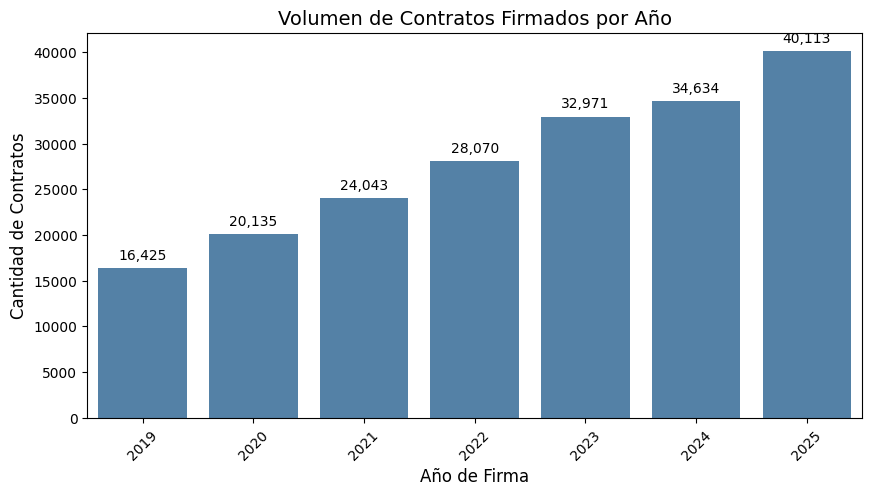

In [10]:
# Evalúa el volumen de contratos por año para justificar el periodo de análisis.
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar formato datetime
df['fecha_de_firma'] = pd.to_datetime(df['fecha_de_firma'], errors='coerce')

# Extraer el año
df['anio_firma'] = df['fecha_de_firma'].dt.year

# Conteo por año
yearly_counts = df['anio_firma'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=yearly_counts.index.astype(int), y=yearly_counts.values, color='steelblue')
plt.title('Volumen de Contratos Firmados por Año', fontsize=14)
plt.xlabel('Año de Firma', fontsize=12)
plt.ylabel('Cantidad de Contratos', fontsize=12)
plt.xticks(rotation=45)

# Agregar etiquetas de datos
for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()


## Limpia calidad de datos, filtra periodo y crea variables objetivo.
#### Tratamiento de calidad de datos
**Nulos:** 
- Existen 2,440 nulos en fecha_de_inicio_del_contrato y 4 en documento_proveedor. Al ser una proporción marginal, la estrategia será imputar la fecha de inicio con la fecha_de_firma y eliminar los 4 registros sin proveedor.
Asumimos que la ejecución de un contrato público suele iniciar el mismo día o muy pocos días después de la fecha de firma (una vez se aprueban las pólizas y el registro presupuestal). Entonces, utilizar la fecha_de_firma como un estimador de la fecha de inicio es una imputación realista.
Por otro lado, la baja proporción de datos faltantes en la columna 'proveedor' (0.002%) es una perdida con muy poca significancia.
- El sector "No aplica/No pertenece" y "No Definido" significan lo mismo. Podríamos agruparlo bajo una etiqueta estandarizada como "SIN CLASIFICAR".

**Conformidad:** 
- La columna duraci_n_del_contrato es texto y mezcla unidades ("Dia(s)", "Mes(es)"). Requiere transformación matemática a una unidad estándar (días).
- En el histograma del logaritmo, hay una pequeña acumulación cerca del cero. Un contrato público con valor_del_contrato = 0 carece de sentido lógico y afectará el modelo.

**Consistencia:** 
- Atributos como departamento y orden contienen la categoría "No Definido", la cual trataremos como una categoría válida ("Desconocido") para no perder registros.
- En las columnas de sector y estado_contrato, observamos valores en minúscula mezclados con mayúsculas iniciales. Aunque no se ven datos duplicados por capitalización, se debe estandarizar todo a mayúsculas o formato título para presentarlos con un formato uniforme.
- Debemos asegurar que la fecha_de_fin_del_contrato sea mayor o igual a la fecha_de_inicio_del_contrato

#### Filtro Temporal (Post-Pandemia)
La gráfica muestra un crecimiento continuo. Los años 2020 y 2021 estuvieron afectados por decretos de emergencia por la pandemia (cambiando modalidades de contratación). Para comparar "manzanas con manzanas", filtraremos el dataset al periodo post-pandemia 2022-2025.

#### Creación de Variables Objetivo (Riesgos/Desviaciones)


In [11]:
# 1. Tratamiento de Calidad de Datos
import numpy as np
import re

df_clean = df.copy()
df_clean = df_clean.dropna(subset=['documento_proveedor'])
df_clean['fecha_de_inicio_del_contrato'] = df_clean['fecha_de_inicio_del_contrato'].fillna(df_clean['fecha_de_firma'])

def parse_duration(val):
    if pd.isna(val) or 'No definido' in str(val): return np.nan
    nums = re.findall(r'\d+', str(val))
    if not nums: return np.nan
    num = int(nums[0])
    if 'Mes' in str(val): return num * 30
    if 'Año' in str(val): return num * 365
    return num # Asume días por defecto

df_clean['duracion_dias'] = df_clean['duraci_n_del_contrato'].apply(parse_duration)
cols_texto = df_clean.select_dtypes(include=['object']).columns
# Excluir columnas técnicas donde las mayúsculas destruyen la información
cols_excluir = ['id_contrato', 'urlproceso', 'documento_proveedor']
cols_aplicar = [col for col in cols_texto if col not in cols_excluir]
# upper() y strip() de forma vectorizada a las columnas pertinentes
for col in cols_aplicar:
    # Convertimos a string primero por seguridad frente a nulos ocultos o mixtos
    df_clean[col] = df_clean[col].astype(str).str.upper().str.strip()

# Renombrar categorías nulas o sin sentido
df_clean['sector'] = df_clean['sector'].replace(['NO APLICA/NO PERTENECE', 'NO DEFINIDO'], 'SIN CLASIFICAR')
# tratar `departamento` y `orden` con "No Definido" como "Desconocido"
df_clean['departamento'] = df_clean['departamento'].replace('NO DEFINIDO', 'DESCONOCIDO')
df_clean['orden'] = df_clean['orden'].replace('NO DEFINIDO', 'DESCONOCIDO')
# Eliminar contratos con valor cero o negativo
df_clean = df_clean[df_clean['valor_del_contrato'] > 0]
# Elimina registros donde el fin es estrictamente menor al inicio
filtro_fechas = df_clean['fecha_de_fin_del_contrato'] >= df_clean['fecha_de_inicio_del_contrato']
df_clean = df_clean[filtro_fechas]

# 2. Filtro Temporal (Post-Pandemia)
df_clean['anio_firma'] = df_clean['fecha_de_firma'].dt.year
df_clean = df_clean[df_clean['anio_firma'] >= 2022]

# 3. Creación de Variables Objetivo (Riesgos/Desviaciones)
# Solo evaluamos presupuesto no ejecutado en contratos terminados o cerrados
contrato_finalizado = df_clean['estado_contrato'].isin(['CERRADO', 'TERMINADO', 'CANCELADO'])

df_clean['riesgo_plazo'] = (df_clean['dias_adicionados'] > 0).astype(int)
df_clean['riesgo_presupuesto'] = (contrato_finalizado & (df_clean['valor_pagado'] < (df_clean['valor_del_contrato'] * 0.95))).astype(int)
df_clean['riesgo_liquidacion'] = ((df_clean['estado_contrato'] == 'TERMINADO') & (df_clean['liquidaci_n'] == 'NO')).astype(int)

# Target unificado: Cualquier desviación
df_clean['desviacion_general'] = (df_clean[['riesgo_plazo', 'riesgo_presupuesto', 'riesgo_liquidacion']].sum(axis=1) > 0).astype(int)

In [12]:
print(f"Dimensiones finales del dataset limpio: {df_clean.shape}")

Dimensiones finales del dataset limpio: (135300, 42)


#### Analisis univariado
**valor_del_contrato:** Magnitud financiera.

**modalidad_de_contratacion:** Refleja el nivel de control (licitación vs. directa).

**sector:** Indica el área de gobierno, útil para focalizar auditorías.

**destino_gasto:** Diferencia inversión pública vs. funcionamiento.

**tipo_de_contrato:** Suministros vs. Compraventa.

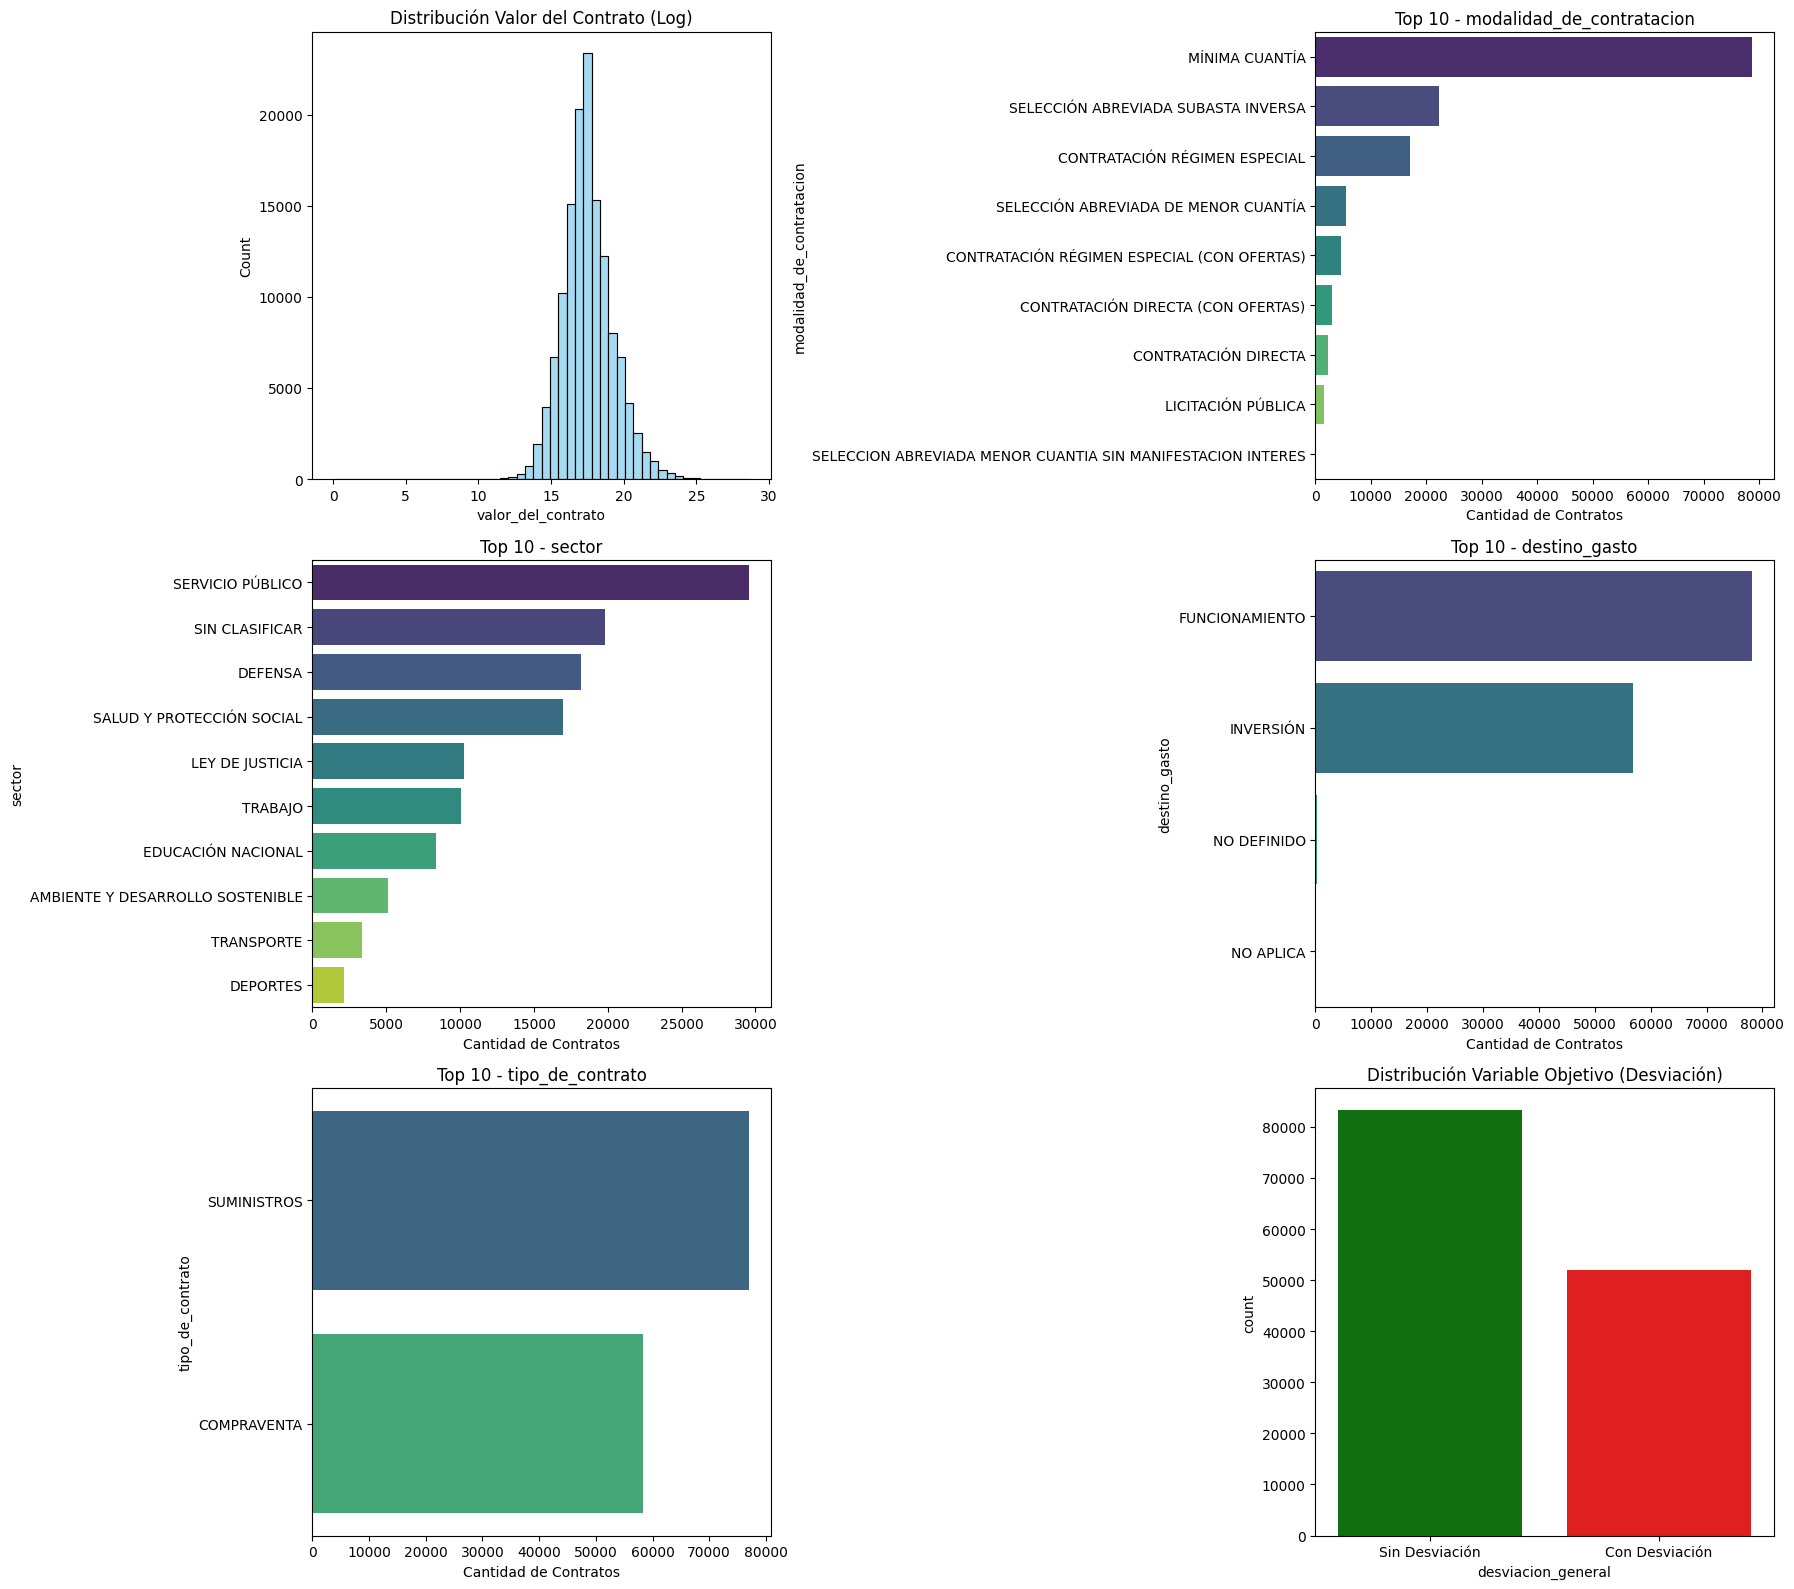

In [13]:
top_5 = ['valor_del_contrato', 'modalidad_de_contratacion', 'sector', 'destino_gasto', 'tipo_de_contrato']
    
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

# 1. Valor del Contrato (Logarítmico por asimetría)
sns.histplot(np.log1p(df_clean['valor_del_contrato']), bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Valor del Contrato (Log)')

# Variables Categóricas
for i, col in enumerate(top_5[1:], 1):
    counts = df_clean[col].value_counts().nlargest(10) # Top 10 categorías
    sns.barplot(y=counts.index, x=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    axes[i].set_title(f'Top 10 - {col}')
    axes[i].set_xlabel('Cantidad de Contratos')

# Target
sns.countplot(x='desviacion_general', data=df_clean, ax=axes[5], palette=['green', 'red'], hue='desviacion_general', legend=False )
axes[5].set_title('Distribución Variable Objetivo (Desviación)')
axes[5].set_xticks([0, 1])
axes[5].set_xticklabels(['Sin Desviación', 'Con Desviación'])

plt.tight_layout()
plt.show()

In [14]:
# 1. valor_del_contrato
vc = df_clean['valor_del_contrato']
print("=== valor_del_contrato ===")
print(f"  Media:    ${vc.mean():,.0f}")
print(f"  Mediana:  ${vc.median():,.0f}")
print(f"  P25:      ${vc.quantile(0.25):,.0f}")
print(f"  P75:      ${vc.quantile(0.75):,.0f}")
print(f"  Mín:      ${vc.min():,.0f}")
print(f"  Máx:      ${vc.max():,.0f}")

# 2-4. Categóricas: top 3 + % sobre total
for col in ['modalidad_de_contratacion', 'sector', 'destino_gasto', 'tipo_de_contrato']:
    counts = df_clean[col].value_counts()
    total = counts.sum()
    print(f"\n=== {col} ===")
    for cat, n in counts.head(3).items():
        print(f"  {cat}: {n:,} ({n/total*100:.1f}%)")

=== valor_del_contrato ===
  Media:    $379,273,577
  Mediana:  $35,686,945
  P25:      $14,022,848
  P75:      $106,157,374
  Mín:      $0
  Máx:      $2,846,224,257,835

=== modalidad_de_contratacion ===
  MÍNIMA CUANTÍA: 78,696 (58.2%)
  SELECCIÓN ABREVIADA SUBASTA INVERSA: 22,379 (16.5%)
  CONTRATACIÓN RÉGIMEN ESPECIAL: 17,127 (12.7%)

=== sector ===
  SERVICIO PÚBLICO: 29,551 (21.8%)
  SIN CLASIFICAR: 19,817 (14.6%)
  DEFENSA: 18,192 (13.4%)

=== destino_gasto ===
  FUNCIONAMIENTO: 78,108 (57.7%)
  INVERSIÓN: 56,926 (42.1%)
  NO DEFINIDO: 263 (0.2%)

=== tipo_de_contrato ===
  SUMINISTROS: 76,986 (56.9%)
  COMPRAVENTA: 58,314 (43.1%)
